# Linear Models Research

## Intro

The analytical solution to the ordinary least squares (OLS) linear regression problem is called the Normal Equation. In vector form, the parameter vector (which minimizes the sum of squared residuals) is expressed as:
$$w=(X^TX)^{-1}X^Ty$$
where:
- *w*: $p \times 1$ vector of optimal weights/coefficients (hypothesis parameters that define it the best)
- *X*: The $N \times p$ design matrix of features (with a column of 1s usually added as the first column for the intercept)
- *y*: The $N \times 1$ vector of actual target values.

To derive it we have to begin with the Residual Sum of Squares (RSS) metric:
$$RSS(w)=(y-Xw)^T(y-Xw)=y^Ty-w^TX^Ty-y^TXw+w^TX^TXw$$

Since the $w^TX^Ty$ is a scalar and equal to its transpose ($y^TXw$), we can combine them:
$$RSS(w)=y^Ty-2w^TX^Ty+w^TX^TXw$$

Take the gradient to the resect to w and set it to zero to find the minimum
$$\nabla_w=-2X^Ty+2X^TXw=0$$

Solve for w
$$2X^TXw=2X^Ty$$
$$X^TXw=X^Ty$$
$$w=(X^TX)^{-1}X^Ty$$

Adding L1 or L2 regularizations to the loss function are leading to some changes. L1, L2 and Elastic Net regularizations are working like a fine to RSS.
-  **Here is L1**:
    $$RSS(w)+fine_{L1}=RSS(w)+\lambda\sum|w|=$$
    > There is no closed-form (analytical) solution in vector form for Lasso because the absolute value function is not differentiable at zero. The solution below is a correct vector-form statement but it just doesn't lead to an explicit formula.
    $$=y^Ty-2w^TX^Ty+w^TX^TXw+\lambda\sum|w|$$

    Take a gradient
    $$\nabla_w=-2X^Ty+2X^TXw+\lambda*sgn(w)=0$$

    Solve for w
    $$2X^TXw+\lambda*sgn(w)=2X^Ty$$
    $$X^TXw+\frac{\lambda*sgn(w)}{2}=X^Ty$$
    $$w=(X^TX)^{-1}(X^Ty-\frac{\lambda*sgn(w)}{2})$$

-  **Here is L2**:
    $$RSS(w)+fine_{L2}=RSS(w)+\lambda\sum{w^2}=$$
    $$=y^Ty-2w^TX^Ty+w^TX^TXw+\lambda{w^Tw}$$

    Take a gradient
    $$\nabla_w=-2X^Ty+2X^TXw+2\lambda{w}=0$$

    Solve for w
    $$2X^TXw+2\lambda{w}=2X^Ty$$
    $$X^TXw+\lambda{w}=X^Ty$$
    $$w(X^TX+\lambda{I})=X^Ty$$
    $$w=(X^TX+\lambda{I})^{-1}X^Ty$$

- **Here is Elastic Net:**
    $$RSS(w)+fine_{ElasticNet}=RSS(w)+\lambda_1\sum|w|+\lambda_2\sum{w^2}=$$
    > There is no closed-form (analytical) solution in vector form for Elastic Net because the absolute value function is not differentiable at zero. The solution below is a correct vector-form statement but it just doesn't lead to an explicit formula.
    $$=y^Ty-2w^TX^Ty+w^TX^TXw+\lambda_1\|w\|_1+\lambda_2{w^Tw}$$

    Take a subgradient
    $$\nabla_w=-2X^Ty+2X^TXw+\lambda_1 \cdot sgn(w)+2\lambda_2{w}=0$$

    Solve for w
    $$2X^TXw+2\lambda_2{w}=2X^Ty-\lambda_1 \cdot sgn(w)$$
    $$(X^TX+\lambda_2{I})w=X^Ty-\frac{\lambda_1}{2} \cdot sgn(w)$$
    $$w=(X^TX+\lambda_2{I})^{-1}\left(X^Ty-\frac{\lambda_1}{2} \cdot sgn(w)\right)$$

## Import

The idea of the next research is to find out the realization of Linear Regression methods with regularization modifications and regularization influence on MAE, RMSE and $R^2$ metrics. There will be measurments on sklearn classes and custom ones from `modules.py`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_json('data/train.json')
df_test = pd.read_json('data/test.json')

In [3]:
df_train.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


## Dataset preparation

In [5]:
# Remove unused symbols ([, ], ', ", and space) from the column `features`
# And get all values in each list and collect the result in one huge list for the whole dataset

changes = str.maketrans({"[": "", "]": "", "'": ""})

def clean_and_collect(features_list):
    """Clean features col and return both cleaned list and collect in global list"""
    if not features_list:
        return []
    
    cleaned = []
    for elem in features_list:
        fixed_elem = elem.translate(changes).replace(' ', '')
        cleaned.append(fixed_elem)
        all_features_list.append(fixed_elem)
    return cleaned

def clean(features_list):
    """Clean features col and return both cleaned list"""
    if not features_list:
        return []
    
    cleaned = []
    for elem in features_list:
        fixed_elem = elem.translate(changes).replace(' ', '')
        cleaned.append(fixed_elem)
    return cleaned

all_features_list = []

df_train['features_cleaned'] = df_train['features'].apply(clean_and_collect)
df_test['features_cleaned'] = df_test['features'].apply(clean)

all_features_list[:5]

['DiningRoom', 'Pre-War', 'LaundryinBuilding', 'Dishwasher', 'HardwoodFloors']

In [6]:
feature_list = list(set(all_features_list)) # list of unique features
print(f'Total values: {len(all_features_list)}')
print(f'Total unique values: {len(feature_list)}')

Total values: 267906
Total unique values: 1546


In [7]:
# We have 1546 unique values. Find top 20 most common ones

from collections import Counter

counter = Counter(all_features_list)
top_20_features = [item[0] for item in counter.most_common(20)]

counter.most_common(20)

[('Elevator', 25915),
 ('CatsAllowed', 23540),
 ('HardwoodFloors', 23527),
 ('DogsAllowed', 22035),
 ('Doorman', 20898),
 ('Dishwasher', 20426),
 ('NoFee', 18062),
 ('LaundryinBuilding', 16344),
 ('FitnessCenter', 13252),
 ('Pre-War', 9148),
 ('LaundryinUnit', 8738),
 ('RoofDeck', 6542),
 ('OutdoorSpace', 5268),
 ('DiningRoom', 5136),
 ('HighSpeedInternet', 4299),
 ('Balcony', 2992),
 ('SwimmingPool', 2730),
 ('LaundryInBuilding', 2593),
 ('NewConstruction', 2559),
 ('Terrace', 2283)]

In [8]:
# Create 20 new features based on the top 20 values: 1 if the value is in the "features" column, otherwise 0.
# For that use custom One-Hot Encoder class

from modules import Custom_OneHotEncoder

onehotencoder = Custom_OneHotEncoder()
df_train = onehotencoder.transform(X=df_train, columns_to_encode=top_20_features, column_to_compare='features')
df_test = onehotencoder.transform(X=df_test, columns_to_encode=top_20_features, column_to_compare='features')

In [9]:
# Extend feature set with 'bathrooms', 'bedrooms'

df_train = df_train[top_20_features + ['bathrooms', 'bedrooms', 'price']]
df_test = df_test[top_20_features + ['bathrooms', 'bedrooms', 'price']]
df_train.head()

,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms,price
0,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1.0,1,2400
1,1,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1.0,2,3800
2,1,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1.0,2,3495
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.5,3,3000
4,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,2795


## Models implementation

In [10]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.base import clone
from modules import custom_R2_coef # Will use custom implementation of R2 metric

In [11]:
# Measure the performance of the model on the train and test datasets with `price` column as target
X_train, y_train = df_train.drop(['price'], axis=1), df_train['price']
X_test, y_test = df_test.drop(['price'], axis=1), df_test['price']

In [12]:
# Create a table with metric to add results of different models
metric_table = pd.DataFrame(columns=['model', 'train_MAE', 'test_MAE', 'train_RMSE', 'test_RMSE', 'train_R2', 'test_R2'])

In [13]:
def fit_predict_pipeline(model, X_train, y_train, X_test, y_test, model_name=None):
    """
    Pipeline for fitting and predicting models.
    """
    active_model = clone(model)
    active_model.fit(X_train, y_train)
    
    
    if model_name is not None:
        results = [model_name]
        print(f'{model_name} fitting done!')
    else:
        results = [model.__class__.__name__]
        print(f'{model.__class__.__name__} fitting done!')
    
    preds = active_model.predict(X_train)
    train_mae_value = mean_absolute_error(y_train, preds)
    train_rmse_value = root_mean_squared_error(y_train, preds)
    train_r2_value = custom_R2_coef(y_train, preds)

    preds = active_model.predict(X_test)
    test_mae_value = mean_absolute_error(y_test, preds)
    test_rmse_value = root_mean_squared_error(y_test, preds)
    test_r2_value = custom_R2_coef(y_test, preds)

    results = results + [train_mae_value, test_mae_value, train_rmse_value, test_rmse_value, train_r2_value, test_r2_value]

    metric_table.loc[len(metric_table)] = results

### Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
from modules import Custom_AnalyticalLinearRegression, Custom_SGDLinearRegression

In [15]:
sklearn_linreg = LinearRegression(fit_intercept=True)
custom_analytical_linreg = Custom_AnalyticalLinearRegression(fit_intercept=True)
custom_sgd_linreg = Custom_SGDLinearRegression(fit_intercept=True)

In [16]:
fit_predict_pipeline(sklearn_linreg, X_train, y_train, X_test, y_test)

fit_predict_pipeline(custom_analytical_linreg, X_train, y_train, X_test, y_test)

fit_predict_pipeline(custom_sgd_linreg, X_train, y_train, X_test, y_test)

LinearRegression fitting done!
Custom_AnalyticalLinearRegression fitting done!
Custom_SGDLinearRegression fitting done!


### Ridge, Lasso, ElasticNet

In [17]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [18]:
sklearn_lasso = Lasso(fit_intercept=True, alpha=1)
custom_lasso = Custom_SGDLinearRegression(fit_intercept=True, regularization='l1', alpha=1)
sklearn_ridge = Ridge(fit_intercept=True, alpha=1)
custom_ridge = Custom_SGDLinearRegression(fit_intercept=True, regularization='l2', alpha=1)
sklearn_elasticnet = ElasticNet(fit_intercept=True, alpha=1, l1_ratio=0.5)
custom_elasticnet = Custom_SGDLinearRegression(fit_intercept=True, regularization='ElasticNet', alpha=1, l1_ratio=0.5)

In [19]:
fit_predict_pipeline(sklearn_lasso, X_train, y_train, X_test, y_test)

fit_predict_pipeline(custom_lasso, X_train, y_train, X_test, y_test, 'Custom_lasso')

fit_predict_pipeline(sklearn_ridge, X_train, y_train, X_test, y_test)

fit_predict_pipeline(custom_ridge, X_train, y_train, X_test, y_test, 'Custom_ridge')

fit_predict_pipeline(sklearn_elasticnet, X_train, y_train, X_test, y_test)

fit_predict_pipeline(custom_elasticnet, X_train, y_train, X_test, y_test, 'Custom_ElasticNet')

Lasso fitting done!
Custom_lasso fitting done!
Ridge fitting done!
Custom_ridge fitting done!
ElasticNet fitting done!
Custom_ElasticNet fitting done!


### MinMaxScaler and StandardScaler

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from modules import Custom_MinMaxScaler, Custom_StandardScaler

In [21]:
scalers = {
    'Sklearn_MinMax': MinMaxScaler(),
    'Custom_MinMax': Custom_MinMaxScaler(),
    'Sklearn_Standard': StandardScaler(),
    'Custom_Standard': Custom_StandardScaler()
}

regressors = {
    'Sklearn_LinReg': LinearRegression(fit_intercept=True),
    'Sklearn_Lasso': Lasso(fit_intercept=True, alpha=1),
    'Sklearn_Ridge': Ridge(fit_intercept=True, alpha=1),
    'Sklearn_ElasticNet': ElasticNet(fit_intercept=True, alpha=1, l1_ratio=0.5),
    
    'Custom_SGD_LinReg': Custom_SGDLinearRegression(fit_intercept=True, regularization='none'),
    'Custom_SGD_Lasso': Custom_SGDLinearRegression(fit_intercept=True, regularization='l1', alpha=1),
    'Custom_SGD_Ridge': Custom_SGDLinearRegression(fit_intercept=True, regularization='l2', alpha=1),
    'Custom_SGD_ElasticNet': Custom_SGDLinearRegression(fit_intercept=True, regularization='ElasticNet', alpha=1, l1_ratio=0.5)
}

for scaler_name, scaler in scalers.items():
    print(f"\n{'='*80}")
    print(f"SCALING: {scaler_name}")
    print('='*80)
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print(f"Scaler fitted on train data")
    
    for regressor_name, regressor in regressors.items():
        model_name = f"{scaler_name}_{regressor_name}"
        
        fit_predict_pipeline(
            regressor,
            X_train_scaled, y_train,
            X_test_scaled, y_test,
            model_name=model_name
        )


SCALING: Sklearn_MinMax
Scaler fitted on train data
Sklearn_MinMax_Sklearn_LinReg fitting done!
Sklearn_MinMax_Sklearn_Lasso fitting done!
Sklearn_MinMax_Sklearn_Ridge fitting done!
Sklearn_MinMax_Sklearn_ElasticNet fitting done!
Sklearn_MinMax_Custom_SGD_LinReg fitting done!
Sklearn_MinMax_Custom_SGD_Lasso fitting done!
Sklearn_MinMax_Custom_SGD_Ridge fitting done!
Sklearn_MinMax_Custom_SGD_ElasticNet fitting done!

SCALING: Custom_MinMax
Scaler fitted on train data
Custom_MinMax_Sklearn_LinReg fitting done!
Custom_MinMax_Sklearn_Lasso fitting done!
Custom_MinMax_Sklearn_Ridge fitting done!
Custom_MinMax_Sklearn_ElasticNet fitting done!


d:\ML2_Supervised_learning.ID_1254799-1\src\modules.py:78: RuntimeWarning: divide by zero encountered in divide
  self.scale_ = (feature_range_max - feature_range_min) / (self.data_max_ - self.data_min_)


Custom_MinMax_Custom_SGD_LinReg fitting done!
Custom_MinMax_Custom_SGD_Lasso fitting done!
Custom_MinMax_Custom_SGD_Ridge fitting done!
Custom_MinMax_Custom_SGD_ElasticNet fitting done!

SCALING: Sklearn_Standard
Scaler fitted on train data
Sklearn_Standard_Sklearn_LinReg fitting done!
Sklearn_Standard_Sklearn_Lasso fitting done!
Sklearn_Standard_Sklearn_Ridge fitting done!
Sklearn_Standard_Sklearn_ElasticNet fitting done!
Sklearn_Standard_Custom_SGD_LinReg fitting done!
Sklearn_Standard_Custom_SGD_Lasso fitting done!
Sklearn_Standard_Custom_SGD_Ridge fitting done!
Sklearn_Standard_Custom_SGD_ElasticNet fitting done!

SCALING: Custom_Standard
Scaler fitted on train data
Custom_Standard_Sklearn_LinReg fitting done!
Custom_Standard_Sklearn_Lasso fitting done!
Custom_Standard_Sklearn_Ridge fitting done!
Custom_Standard_Sklearn_ElasticNet fitting done!
Custom_Standard_Custom_SGD_LinReg fitting done!
Custom_Standard_Custom_SGD_Lasso fitting done!
Custom_Standard_Custom_SGD_Ridge fitting don

### Polynomial features

In [22]:
from sklearn.preprocessing import PolynomialFeatures

In [23]:
pol_features = PolynomialFeatures(degree=10, include_bias=False)
scaler = StandardScaler()

X_train_pol = pol_features.fit_transform(X_train[['bathrooms', 'bedrooms']])
X_train_pol_scaled = scaler.fit_transform(X_train_pol)
X_test_pol_scaled = scaler.transform(pol_features.transform(X_test[['bathrooms', 'bedrooms']]))

fit_predict_pipeline(sklearn_linreg, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Sklearn_LinReg')
fit_predict_pipeline(custom_analytical_linreg, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Custom_Anal_LinReg')
fit_predict_pipeline(custom_sgd_linreg, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Custom_SGD_LinReg')
fit_predict_pipeline(sklearn_lasso, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Sklearn_lasso')
fit_predict_pipeline(custom_lasso, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Custom_lasso')
fit_predict_pipeline(sklearn_ridge, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Sklearn_ridge')
fit_predict_pipeline(custom_ridge, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Custom_ridge')
fit_predict_pipeline(sklearn_elasticnet, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Sklearn_ElasticNet')
fit_predict_pipeline(custom_elasticnet, X_train_pol_scaled, y_train, X_test_pol_scaled, y_test, 'Poly_Custom_ElasticNet')

Poly_Sklearn_LinReg fitting done!
Poly_Custom_Anal_LinReg fitting done!
Poly_Custom_SGD_LinReg fitting done!


d:\Download\distrib\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.019e+11, tolerance: 2.403e+09
  model = cd_fast.enet_coordinate_descent(


Poly_Sklearn_lasso fitting done!
Poly_Custom_lasso fitting done!
Poly_Sklearn_ridge fitting done!
Poly_Custom_ridge fitting done!
Poly_Sklearn_ElasticNet fitting done!
Poly_Custom_ElasticNet fitting done!


### Native

In [24]:
train_median_preds = np.full(len(df_train), df_train['price'].median())
train_mean_preds = np.full(len(df_train), df_train['price'].mean())

train_median_mae = mean_absolute_error(df_train['price'], train_median_preds)
train_median_rmse = root_mean_squared_error(df_train['price'], train_median_preds)
train_median_r2 = custom_R2_coef(df_train['price'], train_median_preds)

train_mean_mae = mean_absolute_error(df_train['price'], train_mean_preds)
train_mean_rmse = root_mean_squared_error(df_train['price'], train_mean_preds)
train_mean_r2 = custom_R2_coef(df_train['price'], train_mean_preds)

test_median_preds = np.full(len(df_test), df_test['price'].median())
test_mean_preds = np.full(len(df_test), df_test['price'].mean())

test_median_mae = mean_absolute_error(df_test['price'], test_median_preds)
test_median_rmse = root_mean_squared_error(df_test['price'], test_median_preds)
test_median_r2 = custom_R2_coef(df_test['price'], test_median_preds)

test_mean_mae = mean_absolute_error(df_test['price'], test_mean_preds)
test_mean_rmse = root_mean_squared_error(df_test['price'], test_mean_preds)
test_mean_r2 = custom_R2_coef(df_test['price'], test_mean_preds)

In [25]:
# train
metric_table.loc[len(metric_table)] = [
    'native_median',
    train_median_mae, test_median_mae,
    train_median_rmse, test_median_rmse,
    train_median_r2, test_median_r2
]

metric_table.loc[len(metric_table)] = [
    'native_mean',
    train_mean_mae, test_mean_mae,
    train_mean_rmse, test_mean_rmse,
    train_mean_r2, test_mean_r2
]

### Outliers

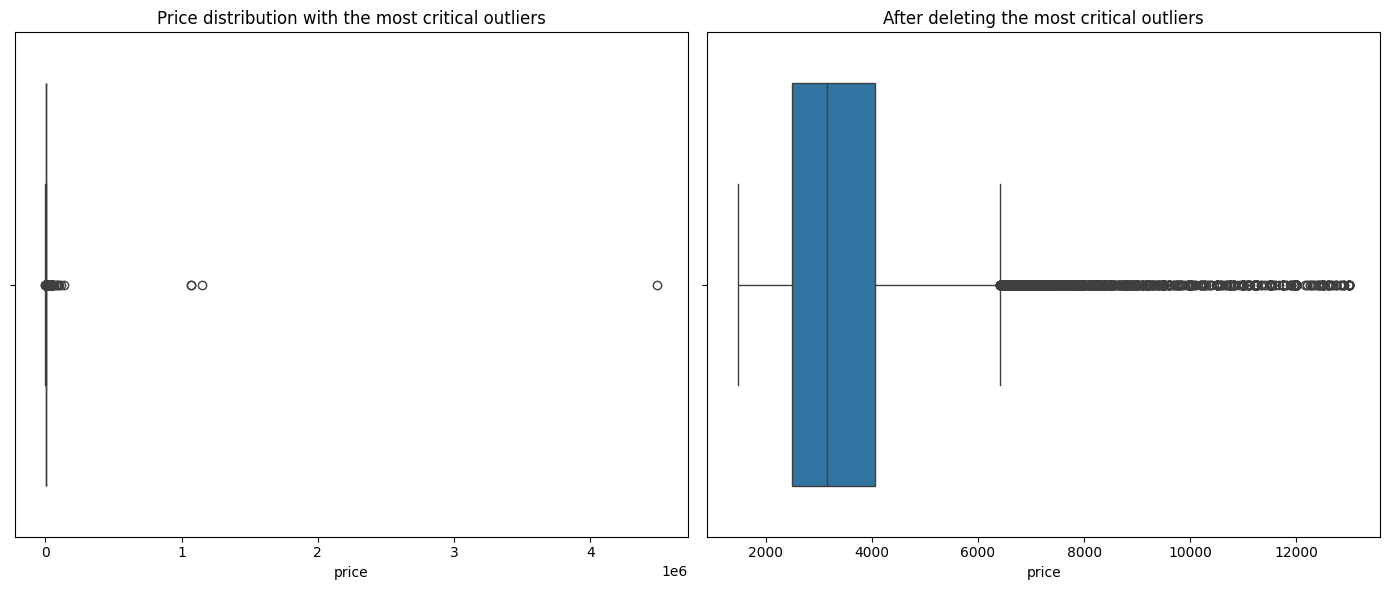

In [26]:
# Drop the most critical outliers
perc_1, perc_99 = np.percentile(df_train['price'], 1), np.percentile(df_train['price'], 99)
df_train_no_outliers = df_train[(df_train['price'] >= perc_1) & (df_train['price'] <= perc_99)]

fig, (ax0, ax1) = plt.subplots(ncols=2, nrows=1, figsize=(14,6))
sns.boxplot(df_train['price'], orient='h', ax=ax0)
ax0.set_title('Price distribution with the most critical outliers')
sns.boxplot(df_train_no_outliers['price'],  orient='h', ax=ax1)
ax1.set_title('After deleting the most critical outliers')

plt.tight_layout()

In [27]:
X_train_no_outliers = df_train_no_outliers.drop('price', axis=1)
y_train_no_outliers = df_train_no_outliers['price']

custom_lasso = Custom_SGDLinearRegression(fit_intercept=True, regularization='l1', alpha=1)
fit_predict_pipeline(custom_lasso, X_train_no_outliers, y_train_no_outliers, X_test, y_test, 'Custom_lasso_no_outliers')

custom_ridge = Custom_SGDLinearRegression(fit_intercept=True, regularization='l2', alpha=1)
fit_predict_pipeline(custom_ridge, X_train_no_outliers, y_train_no_outliers, X_test, y_test, 'Custom_ridge_no_outliers')

custom_elasticnet = Custom_SGDLinearRegression(fit_intercept=True, regularization='ElasticNet', alpha=1, l1_ratio=0.5)
fit_predict_pipeline(custom_elasticnet, X_train_no_outliers, y_train_no_outliers, X_test, y_test, 'Custom_ElasticNet_no_outliers')

Custom_lasso_no_outliers fitting done!
Custom_ridge_no_outliers fitting done!
Custom_ElasticNet_no_outliers fitting done!


## Results

In [28]:
pd.set_option('display.float_format', '{:.2f}'.format)
metric_table

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegression,1122.16,1050.44,22001.50,9628.17,0.01,0.02
1,Custom_AnalyticalLinearRegression,1122.16,1050.44,22001.50,9628.17,0.01,0.02
2,Custom_SGDLinearRegression,1101.40,1026.20,22020.70,9620.12,0.00,0.02
3,Lasso,1120.77,1049.11,22001.50,9627.98,0.01,0.02
4,Custom_lasso,1101.40,1026.20,22020.70,9620.13,0.00,0.02
5,Ridge,1122.13,1050.42,22001.50,9628.16,0.01,0.02
6,Custom_ridge,1115.75,1040.49,22030.52,9637.13,0.00,0.02
7,ElasticNet,1138.34,1065.09,22017.71,9615.74,0.00,0.02
8,Custom_ElasticNet,1098.00,1022.86,22024.99,9627.12,0.00,0.02
9,Sklearn_MinMax_Sklearn_LinReg,1122.16,1050.44,22001.50,9628.17,0.01,0.02


## Key Findings

### 1. Regularization Impact

L1 and L2 regularization alone showed almost no improvement over vanilla Linear Regression, achieving test R² around 0.02. ElasticNet with StandardScaler performed best (test RMSE = 9609), but improvements remained modest. Without scaling, regularization had virtually no effect.

### 2. Outlier Removal Effect

Removing outliers dramatically improved train R² from near zero to 0.45 for Lasso, but test R² stayed at 0.01-0.02, unchanged from full data. This indicates distribution shift between train and test sets, where high-price properties contain real signal that removal destroyed.

### 3. Custom vs Scikit-learn

The analytical custom Linear Regression matched sklearn perfectly. SGD-based custom models failed without scaling (negative R²), while sklearn handled unscaled data robustly. With scaling, custom models approached but remained slightly behind sklearn, particularly for ElasticNet. Sklearn's coordinate descent proved faster and more stable than custom SGD.

### 4. Polynomial Features

Polynomial features (degree 10) without scaling caused numerical overflow, producing test R² values in the negative billions. This demonstrates why feature scaling is mandatory before polynomial expansion.